# Sensing Data Profiling
Profiles the sensing.csv file which contains mobile sensor data at three temporal
resolutions: full day (ep_0), sub-day periods (ep_1/ep_2/ep_3), and hourly (hr_*).

Six feature groups: activity, audio, phone usage, location/mobility, sleep, media. Android and iOS students have different feature availability.

Goals:
- Understand file structure and column inventory
- Profile platform split and its impact on features
- Assess data quality and missingness per group
- Evaluate weekly aggregation feasibility
- Identify which features are viable for Phase 2 engineering

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
SENSING_PATH     = "../../data/raw/college_experience_dataset/Sensing/sensing.csv"
GENERAL_EMA_PATH = "../../data/raw/college_experience_dataset/EMA/general_ema.csv"

EXCLUDE_UIDS = [
    "c0b0998fe60a905081764378d1102494",
    "ea716dd032aaa0dcf8bfa36b1811917f",
    "ad15fc229da933fbf1fc0f92fc9b55a3",
]

In [3]:
df = pd.read_csv(SENSING_PATH)
df["date"] = pd.to_datetime(df["day"].astype(str), format="%Y%m%d")
df["year_week"] = (
    df["date"].dt.isocalendar().year.astype(str) + "-W" +
    df["date"].dt.isocalendar().week.astype(str).str.zfill(2)
)

print(f"Shape    : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Students : {df['uid'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

# Classify columns by group and resolution
def classify_columns(cols):
    groups = {
        "activity":   [c for c in cols if c.startswith("act_")],
        "audio":      [c for c in cols if c.startswith("audio_")],
        "phone":      [c for c in cols if any(c.startswith(p) for p in
                        ["unlock_", "call_", "sms_"])],
        "location":   [c for c in cols if c.startswith("loc_")],
        "sleep":      [c for c in cols if c.startswith("sleep_")],
        "media":      [c for c in cols if c.startswith("other_playing")],
        "quality":    [c for c in cols if c.startswith("quality_")],
        "steps":      [c for c in cols if c.startswith("step")],
        "meta":       ["uid", "is_ios", "day", "date", "year_week"],
    }
    ep0   = [c for c in cols if "_ep_0" in c]
    ep123 = [c for c in cols if any(f"_ep_{i}" in c for i in [1,2,3])]
    hourly = [c for c in cols if "_hr_" in c]
    return groups, ep0, ep123, hourly

groups, ep0_cols, ep123_cols, hourly_cols = classify_columns(df.columns.tolist())

print(f"\nColumn counts by resolution:")
print(f"  Full-day (ep_0)        : {len(ep0_cols)}")
print(f"  Sub-day (ep_1/2/3)     : {len(ep123_cols)}")
print(f"  Hourly (hr_*)          : {len(hourly_cols)}")
print(f"  Other/meta             : {df.shape[1] - len(ep0_cols) - len(ep123_cols) - len(hourly_cols)}")

print(f"\nColumn counts by feature group:")
for grp, cols in groups.items():
    print(f"  {grp:<12}: {len(cols)} columns")

C:\Users\krist\AppData\Local\Temp\ipykernel_42764\2201623097.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["date"] = pd.to_datetime(df["day"].astype(str), format="%Y%m%d")
C:\Users\krist\AppData\Local\Temp\ipykernel_42764\2201623097.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["year_week"] = (


Shape    : 216,065 rows x 653 columns
Students : 220
Date range: 2017-09-07 to 2022-06-15

Column counts by resolution:
  Full-day (ep_0)        : 27
  Sub-day (ep_1/2/3)     : 81
  Hourly (hr_*)          : 480
  Other/meta             : 65

Column counts by feature group:
  activity    : 216 columns
  audio       : 140 columns
  phone       : 84 columns
  location    : 136 columns
  sleep       : 4 columns
  media       : 56 columns
  quality     : 4 columns
  steps       : 0 columns
  meta        : 5 columns


### Platform Split — Android vs iOS

Android and iOS students have different sensor availability. This is the most
important structural challenge in the sensing data. Before profiling feature groups,
the platform split must be understood so missingness is interpreted correctly.

In [4]:
# Per-student platform — use the most common is_ios value per student
platform = (
    df.groupby("uid")["is_ios"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    .reset_index()
    .rename(columns={"is_ios": "platform"})
)
platform["platform_label"] = platform["platform"].map({1: "iOS", 0: "Android"})

n_ios     = (platform["platform"] == 1).sum()
n_android = (platform["platform"] == 0).sum()
n_unknown = platform["platform"].isna().sum()

print(f"Platform distribution across {len(platform)} students with sensing data:")
print(f"  iOS     : {n_ios}  ({n_ios/len(platform)*100:.1f}%)")
print(f"  Android : {n_android}  ({n_android/len(platform)*100:.1f}%)")
print(f"  Unknown : {n_unknown}")

# Load general_ema clean student list for cross-reference
df_ema = pd.read_csv(GENERAL_EMA_PATH)
df_ema = df_ema[~df_ema["uid"].isin(EXCLUDE_UIDS)]
ema_uids = set(df_ema["uid"].unique())
sensing_uids = set(df["uid"].unique())

overlap    = ema_uids & sensing_uids
only_ema   = ema_uids - sensing_uids
only_sens  = sensing_uids - ema_uids

print(f"\nStudent overlap with general_ema (217 clean students):")
print(f"  In both EMA and sensing  : {len(overlap)}")
print(f"  Only in EMA              : {len(only_ema)}")
print(f"  Only in sensing          : {len(only_sens)}")
print(f"  Overlap rate             : {len(overlap)/len(ema_uids)*100:.1f}%")

# Platform breakdown for overlapping students only
platform_overlap = platform[platform["uid"].isin(overlap)]
print(f"\nPlatform split for overlapping students:")
print(platform_overlap["platform_label"].value_counts())

Platform distribution across 220 students with sensing data:
  iOS     : 194  (88.2%)
  Android : 26  (11.8%)
  Unknown : 0

Student overlap with general_ema (217 clean students):
  In both EMA and sensing  : 217
  Only in EMA              : 0
  Only in sensing          : 3
  Overlap rate             : 100.0%

Platform split for overlapping students:
platform_label
iOS        191
Android     26
Name: count, dtype: int64


In [5]:
# Only use students in the EMA-sensing overlap
df_clean = df[df["uid"].isin(overlap)].copy()

print(f"Sensing data for overlapping students:")
print(f"  Rows     : {len(df_clean):,}")
print(f"  Students : {df_clean['uid'].nunique()}")
print(f"  Date range: {df_clean['date'].min().date()} to {df_clean['date'].max().date()}")

# Per-student date span
per_student = (
    df_clean.groupby("uid")["date"]
    .agg(start="min", end="max")
    .assign(span_days=lambda x: (x["end"] - x["start"]).dt.days + 1,
            actual_days=df_clean.groupby("uid").size())
)
per_student["missing_days"] = per_student["span_days"] - per_student["actual_days"]
per_student["pct_missing"] = (per_student["missing_days"] / per_student["span_days"] * 100).round(2)

print(f"\nPer-student span summary (days):")
print(per_student[["span_days", "actual_days", "missing_days", "pct_missing"]].describe().round(1))

Sensing data for overlapping students:
  Rows     : 215,931
  Students : 217
  Date range: 2017-09-07 to 2022-06-15

Per-student span summary (days):
       span_days  actual_days  missing_days  pct_missing
count      217.0        217.0         217.0        217.0
mean      1099.3        995.1         104.2         10.4
std        363.5        367.7         126.3         13.7
min          4.0          2.0           0.0          0.0
25%        961.0        771.0          18.0          1.6
50%       1311.0       1144.0          58.0          5.0
75%       1340.0       1283.0         140.0         13.2
max       1378.0       1370.0         692.0         92.5


### Data Quality Flags

Quality columns measure hours of sensor coverage per day (max=24).
Days with very low quality (e.g. below 20 hours) should be filtered before
weekly aggregation in Phase 2, as they represent days where the sensor
was inactive for a significant portion of the day.

`quality_activity` and `quality_loc` are available for all students.
`quality_audio` and `quality_light` are Android only.

Quality columns: ['quality_activity', 'quality_audio', 'quality_light', 'quality_loc']

quality_activity (n=215,931):
  Mean: 21.8h  Median: 24.0h  Min: 0.0h  Max: 24.0h
  Days with quality < 20h: 40,362 (18.7%)
  Days with quality < 12h: 8,865 (4.1%)

quality_audio (n=215,931):
  Mean: 5.5h  Median: 0.0h  Min: 0.0h  Max: 24.0h
  Days with quality < 20h: 169,109 (78.3%)
  Days with quality < 12h: 164,118 (76.0%)

quality_light (n=25,105):
  Mean: 20.7h  Median: 24.0h  Min: 0.0h  Max: 24.0h
  Days with quality < 20h: 4,255 (16.9%)
  Days with quality < 12h: 3,070 (12.2%)

quality_loc (n=215,931):
  Mean: 17.9h  Median: 24.0h  Min: 0.0h  Max: 24.0h
  Days with quality < 20h: 64,279 (29.8%)
  Days with quality < 12h: 50,491 (23.4%)


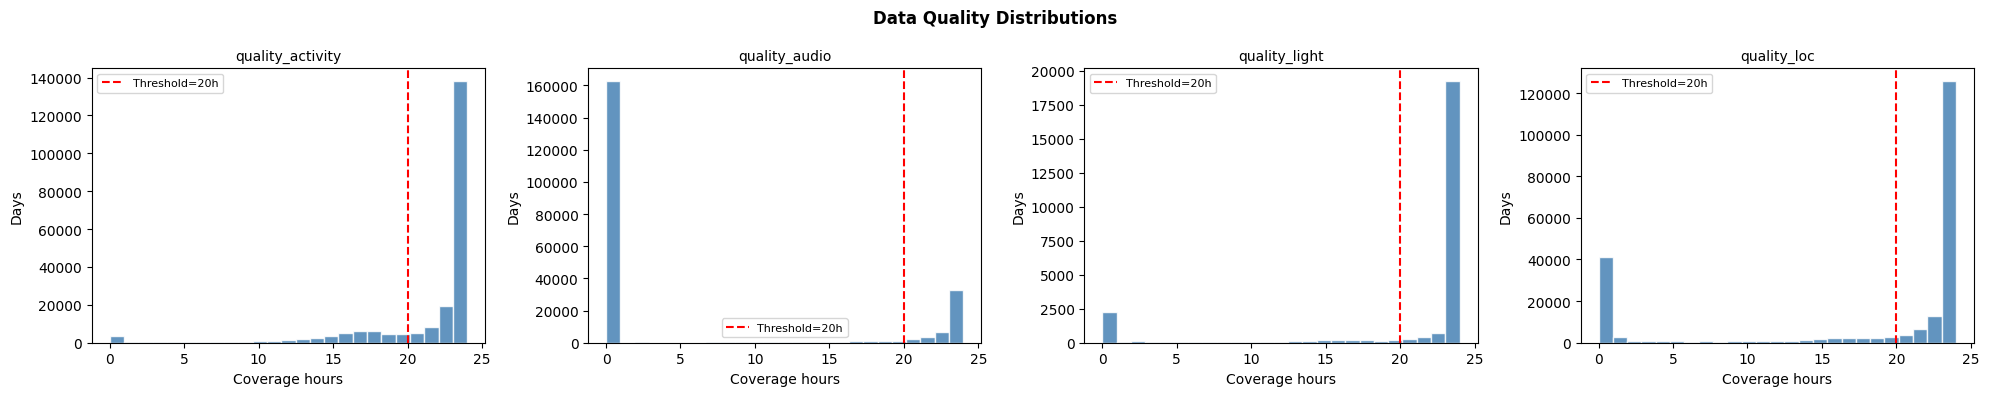

In [7]:
quality_cols = groups["quality"]
print(f"Quality columns: {quality_cols}")

for col in quality_cols:
    data = df_clean[col].dropna()
    if len(data) == 0:
        print(f"\n{col}: no data")
        continue
    print(f"\n{col} (n={len(data):,}):")
    print(f"  Mean: {data.mean():.1f}h  Median: {data.median():.1f}h  "
          f"Min: {data.min():.1f}h  Max: {data.max():.1f}h")
    print(f"  Days with quality < 20h: {(data < 20).sum():,} ({(data < 20).mean()*100:.1f}%)")
    print(f"  Days with quality < 12h: {(data < 12).sum():,} ({(data < 12).mean()*100:.1f}%)")

# Threshold 
fig, axes = plt.subplots(1, len(quality_cols), figsize=(5 * len(quality_cols), 4))
if len(quality_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, quality_cols):
    data = df_clean[col].dropna()
    ax.hist(data, bins=25, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(20, color="red", linestyle="--", linewidth=1.5, label="Threshold=20h")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Coverage hours")
    ax.set_ylabel("Days")
    ax.legend(fontsize=8)

plt.suptitle("Data Quality Distributions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../outputs/figures/sensing_quality_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Missingness Per Feature Group

For each feature group, the percentage of student-days where all ep_0 columns
in that group are null is computed. This represents days with no data for that
sensor type. Broken down by platform to correctly attribute missingness -
a group that is "Android only" will be 100% missing for iOS students by design.

In [8]:
platform_map = platform.set_index("uid")["platform"]
df_clean["is_ios"] = df_clean["uid"].map(platform_map)

results = []
for grp_name, grp_cols in groups.items():
    if grp_name in ["meta", "quality"]:
        continue
    ep0 = [c for c in grp_cols if "_ep_0" in c or
           (grp_name == "sleep" and c in
            ["sleep_duration", "sleep_start", "sleep_end", "sleep_heathkit_dur"])]
    if not ep0:
        ep0 = grp_cols[:1] if grp_cols else []
    if not ep0:
        continue

    for platform_val, platform_label in [(0, "Android"), (1, "iOS"), (None, "All")]:
        if platform_val is None:
            subset = df_clean
        else:
            subset = df_clean[df_clean["is_ios"] == platform_val]
        if len(subset) == 0:
            continue

        existing = [c for c in ep0 if c in subset.columns]
        if not existing:
            continue

        all_null = subset[existing].isna().all(axis=1).mean() * 100
        results.append({
            "group":    grp_name,
            "platform": platform_label,
            "n_rows":   len(subset),
            "pct_all_null": round(all_null, 1),
        })

miss_df = pd.DataFrame(results)
print("Missingness per feature group (% of days fully missing):")
pivot = miss_df.pivot(index="group", columns="platform", values="pct_all_null")
print(pivot.to_string())

Missingness per feature group (% of days fully missing):
platform   All  Android   iOS
group                        
activity   0.0      0.0   0.0
audio      0.0      0.0   0.0
location  19.1      3.1  21.1
media     11.6     93.8   1.1
phone      0.0      0.0   0.0
sleep      0.0      0.0   0.0


### Key Feature Distributions

One representative ep_0 feature per group is plotted across all valid days.
The goal is to check for outliers, implausible values, and skew that would
affect aggregation in Phase 2. Only days with non-null values are included.

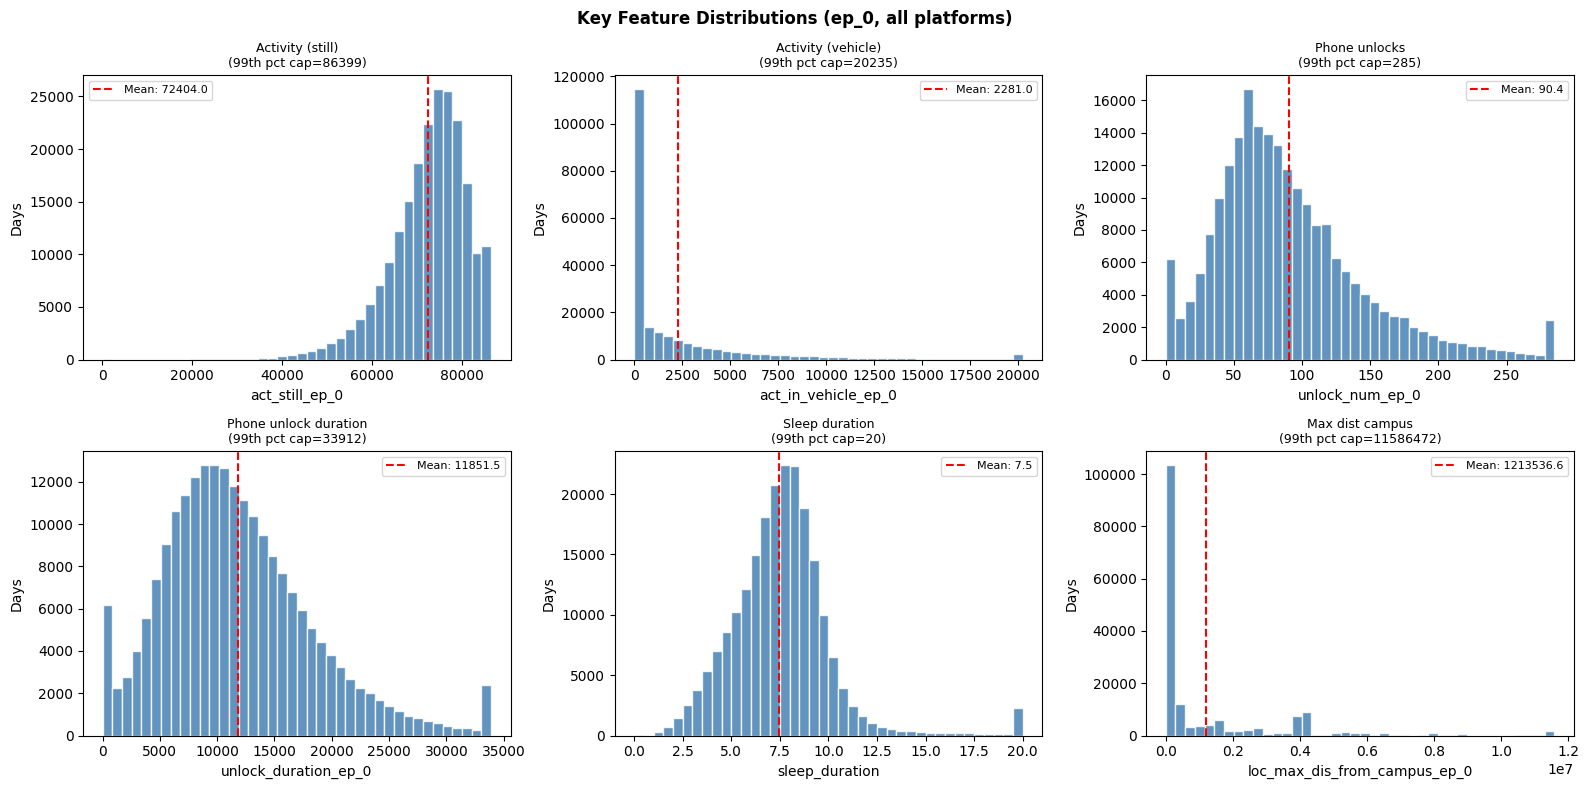

Summary statistics for key features:
       act_still_ep_0  act_in_vehicle_ep_0  unlock_num_ep_0  \
count       215931.00            215931.00        215931.00   
mean         72404.04              2281.01            90.39   
std           8581.29              4299.32            57.70   
min             52.00                 0.00             0.00   
25%          67879.00                 0.00            53.00   
50%          73772.00               306.00            79.00   
75%          78329.50              2772.00           115.00   
max          86400.00             75644.00           754.00   

       unlock_duration_ep_0  sleep_duration  loc_max_dis_from_campus_ep_0  
count             215931.00       215931.00                     170308.00  
mean               11851.53            7.47                    1213536.62  
std                 6891.17            2.76                    2252765.86  
min                    0.00            0.00                         40.94  
25%            

In [9]:
# One representative feature per group that is available to all students
representative = {
    "Activity (still)"    : "act_still_ep_0",
    "Activity (vehicle)"  : "act_in_vehicle_ep_0",
    "Phone unlocks"       : "unlock_num_ep_0",
    "Phone unlock duration": "unlock_duration_ep_0",
    "Sleep duration"      : "sleep_duration",
    "Max dist campus"     : "loc_max_dis_from_campus_ep_0",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (label, col) in enumerate(representative.items()):
    if col not in df_clean.columns:
        axes[i].set_title(f"{label}\n(not in file)", fontsize=9)
        continue
    data = df_clean[col].dropna()
    # Cap extreme outliers at 99th percentile for visualization
    cap = data.quantile(0.99)
    data_capped = data.clip(upper=cap)
    axes[i].hist(data_capped, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].axvline(data.mean(), color="red", linestyle="--",
                    linewidth=1.5, label=f"Mean: {data.mean():.1f}")
    axes[i].set_title(f"{label}\n(99th pct cap={cap:.0f})", fontsize=9)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Days")
    axes[i].legend(fontsize=8)

plt.suptitle("Key Feature Distributions (ep_0, all platforms)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../outputs/figures/sensing_key_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print summary stats
print("Summary statistics for key features:")
valid_cols = [c for c in representative.values() if c in df_clean.columns]
print(df_clean[valid_cols].describe().round(2))

### Hourly Column Structure

The file contains hourly columns (hr_0 to hr_23) for several feature types.
These enable time of day pattern analysis.

For Phase 2, the decision is whether to:
- Use ep_0 only (simplest, daily aggregates)
- Use ep_1/ep_2/ep_3 (captures time-of-day periods already defined)
- Use hourly columns (richest but highest dimensionality and sparsity)

The ep_1/ep_2/ep_3 approach is recommended as it balances richness and manageability.
This section verifies the hourly columns are populated and shows an example pattern.

Hourly unlock_duration columns found: 24
Hours covered: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23']


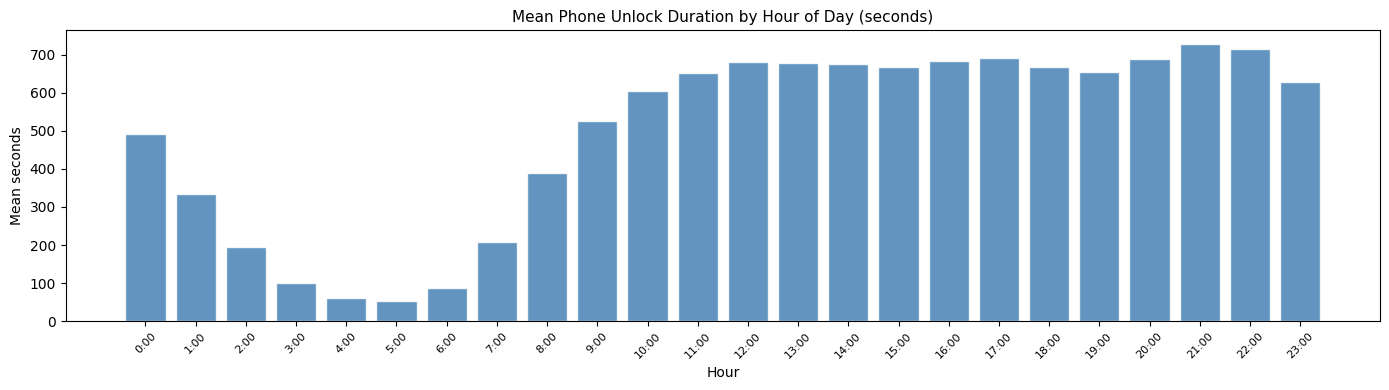


Peak phone use hour : 21:00
Lowest use hour     : 5:00

Coverage comparison for unlock_duration (non-null rows):
  Full day (ep_0): 215,931 non-null rows (100.0%)
  Night (ep_1): 215,931 non-null rows (100.0%)
  Daytime (ep_2): 215,931 non-null rows (100.0%)
  Evening (ep_3): 215,931 non-null rows (100.0%)


In [10]:
unlock_hr_cols = sorted([c for c in df_clean.columns if c.startswith("unlock_duration_hr_")],
                         key=lambda x: int(x.split("_")[-1]))

print(f"Hourly unlock_duration columns found: {len(unlock_hr_cols)}")
print(f"Hours covered: {[c.split('_')[-1] for c in unlock_hr_cols]}")

if unlock_hr_cols:
    hourly_means = df_clean[unlock_hr_cols].mean()
    hourly_means.index = [int(c.split("_")[-1]) for c in unlock_hr_cols]
    hourly_means = hourly_means.sort_index()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(hourly_means.index, hourly_means.values,
           color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_xticks(range(0, 24))
    ax.set_xticklabels([f"{h}:00" for h in range(24)], rotation=45, fontsize=8)
    ax.set_title("Mean Phone Unlock Duration by Hour of Day (seconds)", fontsize=11)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Mean seconds")
    plt.tight_layout()
    plt.savefig("../../outputs/figures/sensing_hourly_unlock_pattern.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nPeak phone use hour : {hourly_means.idxmax()}:00")
    print(f"Lowest use hour     : {hourly_means.idxmin()}:00")

# Compare ep_0 vs ep_1/ep_2/ep_3 coverage
ep_cols = {
    "Full day (ep_0)"  : "unlock_duration_ep_0",
    "Night (ep_1)"     : "unlock_duration_ep_1",
    "Daytime (ep_2)"   : "unlock_duration_ep_2",
    "Evening (ep_3)"   : "unlock_duration_ep_3",
}
print(f"\nCoverage comparison for unlock_duration (non-null rows):")
for label, col in ep_cols.items():
    if col in df_clean.columns:
        n = df_clean[col].notna().sum()
        print(f"  {label}: {n:,} non-null rows ({n/len(df_clean)*100:.1f}%)")

### Sleep Feature Analysis

Sleep is often the strongest behavioral predictor of mental health.
The file contains three sleep columns:
- `sleep_duration` - total sleep in hours (All platforms)
- `sleep_start` and `sleep_end` - in 7.5-minute epochs starting at 8 PM
- `sleep_heathkit_dur` - iOS HealthKit sleep duration (iOS only)

Sleep start and end require conversion from epoch units to clock time:
  clock_time = 20:00 + (value x 7.5 minutes)
For example: value=40 → 40 x 7.5 = 300 minutes = 5 hours after 8 PM = 1:00 AM

Days with sleep data: 215,931 / 215,931 (100.0%)

Sleep duration (hours):
count    215931.00
mean          7.47
std           2.76
min           0.00
25%           6.00
50%           7.50
75%           8.75
max          23.75
Name: sleep_duration, dtype: float64

Sleep start time (hour of day, 0=midnight):
count    215931.00
mean          8.48
std           9.64
min           0.00
25%           1.25
50%           2.75
75%          21.75
max          23.88
Name: sleep_start_hr, dtype: float64

Sleep end time (hour of day, 0=midnight):
count    215931.00
mean          8.55
std           2.57
min           0.00
25%           7.25
50%           8.25
75%           9.50
max          23.75
Name: sleep_end_hr, dtype: float64


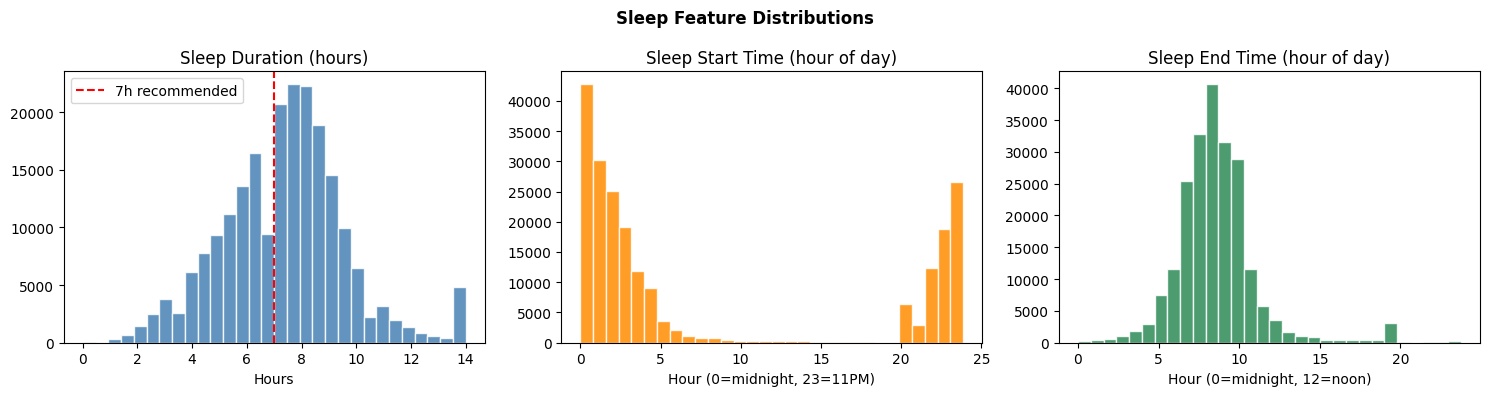

In [11]:
def epoch_to_hour(epoch_val):
    """Convert 7.5-minute epochs from 8 PM to decimal clock hour (0-24)."""
    minutes_after_8pm = epoch_val * 7.5
    hour_of_day = (20 + minutes_after_8pm / 60) % 24
    return hour_of_day

sleep_data = df_clean[["uid", "date", "sleep_duration",
                         "sleep_start", "sleep_end"]].copy()

sleep_valid = sleep_data[sleep_data["sleep_duration"].notna()].copy()

if "sleep_start" in sleep_valid.columns:
    sleep_valid["sleep_start_hr"] = sleep_valid["sleep_start"].apply(
        lambda x: epoch_to_hour(x) if pd.notna(x) else np.nan
    )
    sleep_valid["sleep_end_hr"] = sleep_valid["sleep_end"].apply(
        lambda x: epoch_to_hour(x) if pd.notna(x) else np.nan
    )

print(f"Days with sleep data: {len(sleep_valid):,} / {len(df_clean):,} "
      f"({len(sleep_valid)/len(df_clean)*100:.1f}%)")

print(f"\nSleep duration (hours):")
print(sleep_valid["sleep_duration"].describe().round(2))

if "sleep_start_hr" in sleep_valid.columns:
    print(f"\nSleep start time (hour of day, 0=midnight):")
    print(sleep_valid["sleep_start_hr"].describe().round(2))
    print(f"\nSleep end time (hour of day, 0=midnight):")
    print(sleep_valid["sleep_end_hr"].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sleep_valid["sleep_duration"].dropna().clip(0, 14),
             bins=30, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(7, color="red", linestyle="--", label="7h recommended")
axes[0].set_title("Sleep Duration (hours)")
axes[0].set_xlabel("Hours")
axes[0].legend()

if "sleep_start_hr" in sleep_valid.columns:
    axes[1].hist(sleep_valid["sleep_start_hr"].dropna(),
                 bins=30, color="darkorange", edgecolor="white", alpha=0.85)
    axes[1].set_title("Sleep Start Time (hour of day)")
    axes[1].set_xlabel("Hour (0=midnight, 23=11PM)")

    axes[2].hist(sleep_valid["sleep_end_hr"].dropna(),
                 bins=30, color="seagreen", edgecolor="white", alpha=0.85)
    axes[2].set_title("Sleep End Time (hour of day)")
    axes[2].set_xlabel("Hour (0=midnight, 12=noon)")

plt.suptitle("Sleep Feature Distributions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../outputs/figures/sensing_sleep_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Weekly Aggregation Feasibility

The model requires weekly feature aggregates. This section measures how
many days of sensing data are available per student per week, and what
percentage of weeks meet a minimum quality threshold.

A week is considered usable for feature engineering if it has at least
4 days of sensing data with quality_activity >= 20 hours.

Quality days per (student, week) - summary:
count    28652.00
mean         6.13
std          1.58
min          1.00
25%          6.00
50%          7.00
75%          7.00
max          7.00
Name: quality_days, dtype: float64

Distribution of quality days per student-week:
  1 days: 1,075 weeks (3.8%)
  2 days: 802 weeks (2.8%)
  3 days: 914 weeks (3.2%)
  4 days: 990 weeks (3.5%)
  5 days: 1,641 weeks (5.7%)
  6 days: 4,627 weeks (16.1%)
  7 days: 18,603 weeks (64.9%)

Weeks with >= 4 quality days : 25,861 (90.3%)
Total (student, week) pairs        : 28,652


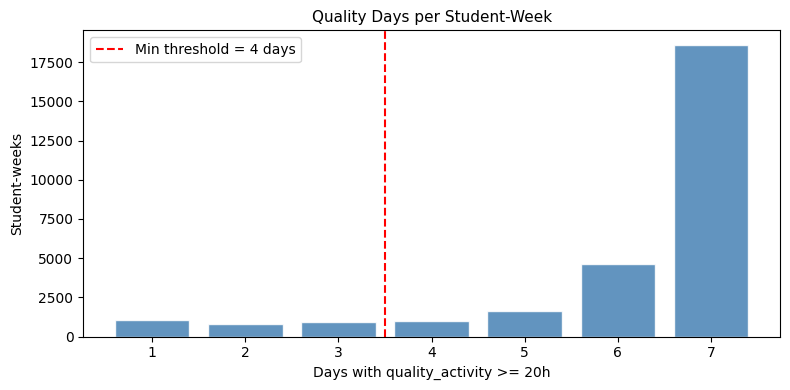

In [12]:
# Apply quality filter
QUALITY_THRESHOLD = 20  # hours

if "quality_activity" in df_clean.columns:
    df_quality = df_clean[df_clean["quality_activity"] >= QUALITY_THRESHOLD].copy()
else:
    df_quality = df_clean.copy()
    print("WARNING: quality_activity not found - using all rows")

# Count quality days per (student, week)
days_per_week = (
    df_quality.groupby(["uid", "year_week"])
    .size()
    .reset_index(name="quality_days")
)

print(f"Quality days per (student, week) - summary:")
print(days_per_week["quality_days"].describe().round(2))

dist = days_per_week["quality_days"].value_counts().sort_index()
print(f"\nDistribution of quality days per student-week:")
for days, count in dist.items():
    pct = count / len(days_per_week) * 100
    print(f"  {days} days: {count:,} weeks ({pct:.1f}%)")

MIN_DAYS = 4
usable = (days_per_week["quality_days"] >= MIN_DAYS).sum()
print(f"\nWeeks with >= {MIN_DAYS} quality days : {usable:,} "
      f"({usable/len(days_per_week)*100:.1f}%)")
print(f"Total (student, week) pairs        : {len(days_per_week):,}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dist.index, dist.values, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(MIN_DAYS - 0.5, color="red", linestyle="--",
           label=f"Min threshold = {MIN_DAYS} days")
ax.set_title("Quality Days per Student-Week", fontsize=11)
ax.set_xlabel("Days with quality_activity >= 20h")
ax.set_ylabel("Student-weeks")
ax.legend()
plt.tight_layout()
plt.savefig("../../outputs/figures/sensing_weekly_coverage.png",
            dpi=150, bbox_inches="tight")
plt.show()